# Módulo 4 · Holt-Winters: suavizado doble y triple

Curso: **Series Temporales con R y Python** (Frogames Formación).

Notebook de acompañamiento de la lección `04-tecnicas-de-suavizado/02-holt-winters-suavizado-doble-y-triple` — ábrelo mientras lees la lección y ejecuta cada celda tú mismo.

Mismo dataset que la lección anterior: pasajeros de avión, mensual, 1949-1960. Aquí vas más allá del suavizado exponencial simple: añades tendencia (Holt) y luego estacionalidad (Holt-Winters).

**Nota de migración**: las funciones `SimpleExpSmoothing`/`ExponentialSmoothing` de `statsmodels` ahora exigen `initialization_method` explícito — antes tenían un valor por defecto implícito. Usamos `'legacy-heuristic'` para reproducir el comportamiento numérico original en el suavizado simple, y `'estimated'` (recomendado hoy) para Holt y Holt-Winters.

In [1]:
import matplotlib.pyplot as plt

# Estilo oscuro opcional, para que los gráficos combinen con el tema del curso.
# No afecta a ningún resultado numérico -- puedes omitir esta celda sin problema.
plt.rcParams.update({
    "figure.facecolor": "#0d0d10", "axes.facecolor": "#0d0d10",
    "axes.edgecolor": "#a8a8b3", "axes.labelcolor": "#e1e1e6",
    "xtick.color": "#a8a8b3", "ytick.color": "#a8a8b3",
    "text.color": "#e1e1e6", "grid.color": "#232326",
    "font.size": 11,
})

## Carga y frecuencia mensual

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("airline_passengers.csv", index_col="Month", parse_dates=True)
df.dropna(inplace=True)
df.index.freq = "MS"
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## Suavizado exponencial simple (SES)

`SimpleExpSmoothing(...).fit(smoothing_level=alpha, optimized=False)` con el mismo `alpha` que EWMA reproduce exactamente el resultado de `.ewm()` — son la misma fórmula.

In [3]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

span = 12
alpha = 2 / (span + 1)
df["EWMA12"] = df["Thousands of Passengers"].ewm(alpha=alpha, adjust=False).mean()
df["SES12"] = (
    SimpleExpSmoothing(df["Thousands of Passengers"], initialization_method="legacy-heuristic")
    .fit(smoothing_level=alpha, optimized=False)
    .fittedvalues
    .shift(-1)
)
df[["Thousands of Passengers", "EWMA12", "SES12"]].head()

,Thousands of Passengers,EWMA12,SES12
Month,,,
1949-01-01,112,112.000000,112.000000
1949-02-01,118,112.923077,112.923077
1949-03-01,132,115.857988,115.857988
1949-04-01,129,117.879836,117.879836
1949-05-01,121,118.359861,118.359861


In [4]:
np.allclose(df["EWMA12"].iloc[:-1], df["SES12"].iloc[:-1])

True

## Suavizado exponencial doble (Holt) — tendencia aditiva

Añade un segundo factor $\beta$ para la tendencia: el modelo ya no solo sigue el nivel, también extrapola hacia dónde se mueve.

In [5]:
df["DESadd12"] = (
    ExponentialSmoothing(df["Thousands of Passengers"], trend="add", initialization_method="estimated")
    .fit()
    .fittedvalues
    .shift(-1)
)
df[["Thousands of Passengers", "EWMA12", "DESadd12"]].head()

,Thousands of Passengers,EWMA12,DESadd12
Month,,,
1949-01-01,112,112.000000,114.237777
1949-02-01,118,112.923077,120.237777
1949-03-01,132,115.857988,134.237777
1949-04-01,129,117.879836,131.237777
1949-05-01,121,118.359861,123.237778


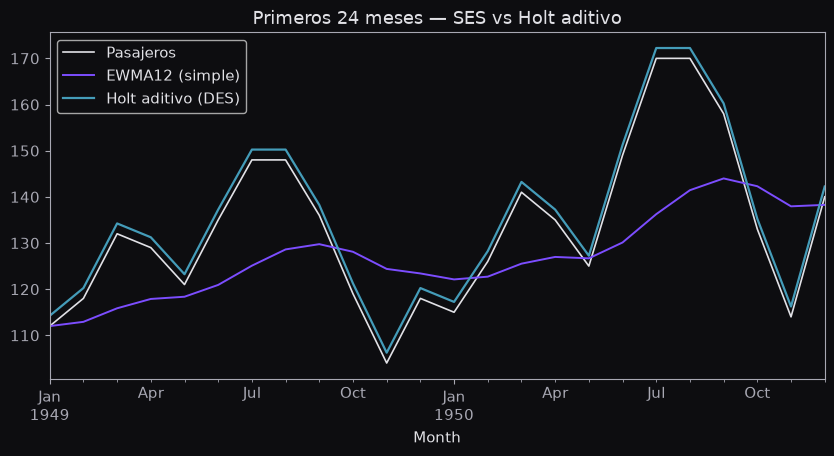

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
df["Thousands of Passengers"].iloc[:24].plot(ax=ax, color="#e1e1e6", linewidth=1.2, label="Pasajeros")
df["EWMA12"].iloc[:24].plot(ax=ax, color="#7c4dff", linewidth=1.4, label="EWMA12 (simple)")
df["DESadd12"].iloc[:24].plot(ax=ax, color="#449cb9", linewidth=1.6, label="Holt aditivo (DES)")
ax.set_title("Primeros 24 meses — SES vs Holt aditivo")
ax.legend()
plt.show()

## Suavizado exponencial doble — tendencia multiplicativa

Si la tendencia es curva (crecimiento porcentual, no lineal), un ajuste multiplicativo encaja mejor que el aditivo.

In [7]:
df["DESmul12"] = (
    ExponentialSmoothing(df["Thousands of Passengers"], trend="mul", initialization_method="estimated")
    .fit()
    .fittedvalues
    .shift(-1)
)
df[["Thousands of Passengers", "DESadd12", "DESmul12"]].head()

,Thousands of Passengers,DESadd12,DESmul12
Month,,,
1949-01-01,112,114.237777,112.049183
1949-02-01,118,120.237777,118.051818
1949-03-01,132,134.237777,132.057965
1949-04-01,129,131.237777,129.056648
1949-05-01,121,123.237778,121.053135


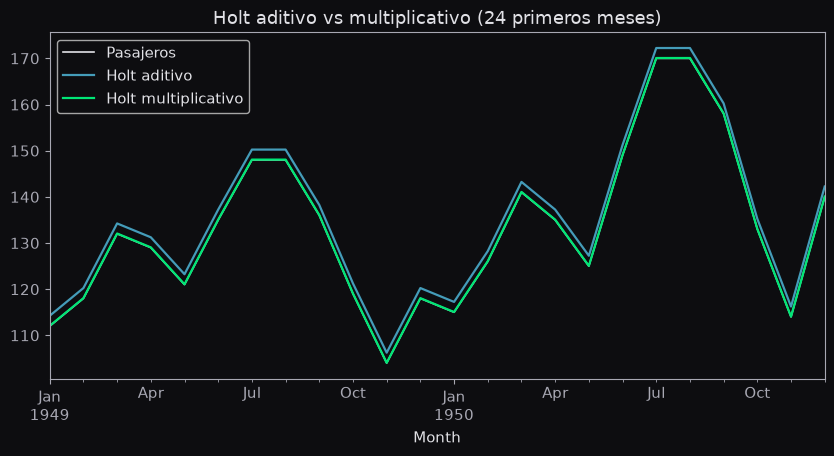

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
df["Thousands of Passengers"].iloc[:24].plot(ax=ax, color="#e1e1e6", linewidth=1.2, label="Pasajeros")
df["DESadd12"].iloc[:24].plot(ax=ax, color="#449cb9", linewidth=1.6, label="Holt aditivo")
df["DESmul12"].iloc[:24].plot(ax=ax, color="#00e676", linewidth=1.6, label="Holt multiplicativo")
ax.set_title("Holt aditivo vs multiplicativo (24 primeros meses)")
ax.legend()
plt.show()

## Suavizado exponencial triple (Holt-Winters)

Añade un tercer factor $\gamma$ para la estacionalidad, con `seasonal_periods=12` (patrón que se repite cada año).

In [9]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df["TESadd12"] = (
        ExponentialSmoothing(
            df["Thousands of Passengers"], trend="add", seasonal="add",
            seasonal_periods=12, initialization_method="estimated",
        ).fit().fittedvalues
    )
    df["TESmul12"] = (
        ExponentialSmoothing(
            df["Thousands of Passengers"], trend="mul", seasonal="mul",
            seasonal_periods=12, initialization_method="estimated",
        ).fit().fittedvalues
    )
df[["Thousands of Passengers", "TESadd12", "TESmul12"]].head()

,Thousands of Passengers,TESadd12,TESmul12
Month,,,
1949-01-01,112,112.000374,111.589224
1949-02-01,118,120.169005,118.830398
1949-03-01,132,134.698807,133.333716
1949-04-01,129,131.378859,127.892236
1949-05-01,121,124.630830,120.991011


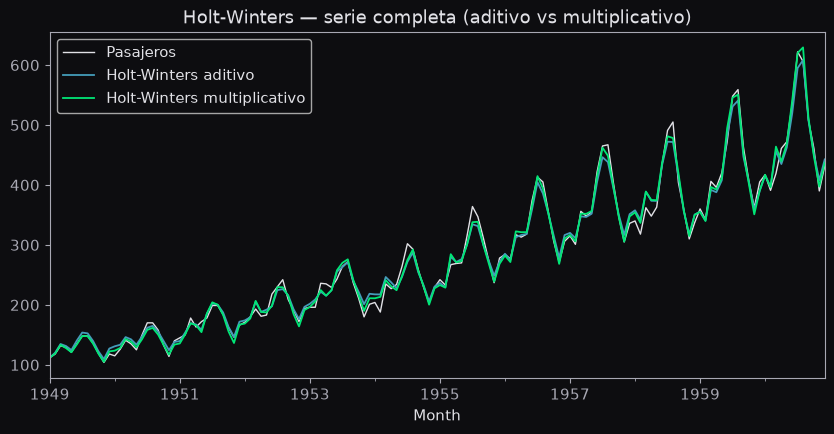

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
df["Thousands of Passengers"].plot(ax=ax, color="#e1e1e6", linewidth=1, label="Pasajeros")
df["TESadd12"].plot(ax=ax, color="#449cb9", linewidth=1.3, label="Holt-Winters aditivo")
df["TESmul12"].plot(ax=ax, color="#00e676", linewidth=1.3, label="Holt-Winters multiplicativo")
ax.set_title("Holt-Winters — serie completa (aditivo vs multiplicativo)")
ax.legend()
plt.show()

## Pronóstico a 36 meses

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_add = ExponentialSmoothing(
        df["Thousands of Passengers"], trend="add", seasonal="add",
        seasonal_periods=12, initialization_method="estimated",
    ).fit()
    model_mul = ExponentialSmoothing(
        df["Thousands of Passengers"], trend="mul", seasonal="mul",
        seasonal_periods=12, initialization_method="estimated",
    ).fit()

forecast_add = model_add.forecast(36)
forecast_mul = model_mul.forecast(36)
forecast_add.head()

1961-01-01    451.577695
1961-02-01    427.258454
1961-03-01    464.699995
1961-04-01    500.104360
1961-05-01    508.662045
Freq: MS, dtype: float64

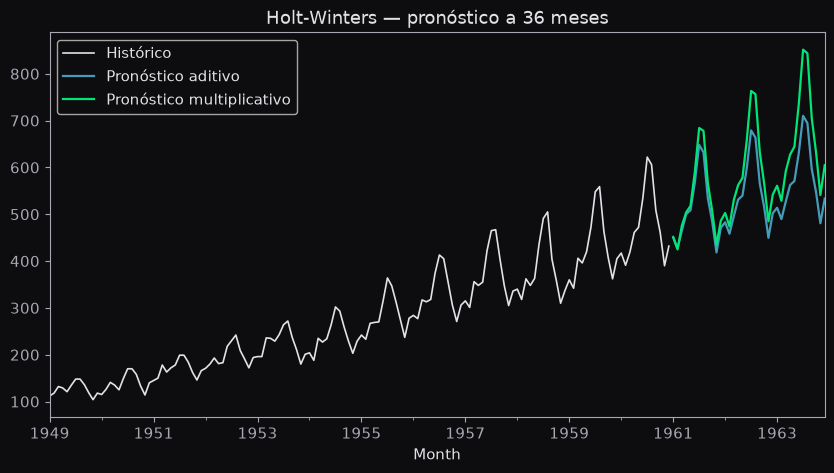

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
df["Thousands of Passengers"].plot(ax=ax, color="#e1e1e6", linewidth=1.2, label="Histórico")
forecast_add.plot(ax=ax, color="#449cb9", linewidth=1.6, label="Pronóstico aditivo")
forecast_mul.plot(ax=ax, color="#00e676", linewidth=1.6, label="Pronóstico multiplicativo")
ax.set_title("Holt-Winters — pronóstico a 36 meses")
ax.legend(loc="upper left")
plt.show()

**Entregable**: reproduce estas celdas y compara los pronósticos aditivo y multiplicativo a partir del mes 12: ¿en qué se diferencian visualmente cuando la amplitud estacional crece con el nivel de la serie? Esa es justo la señal que distingue "estacionalidad aditiva" de "estacionalidad multiplicativa" en la práctica, no solo en la fórmula.